# 多步预测对比实验

本实验对比不同预测步长（HORIZON）下模型的预测性能，分析单步预测与多步预测的差异。

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import joblib

from src import (
    load_data,
    create_sequences,
    LSTMPredictor,
    set_seed,
    evaluate,
    LoadDataset,
    EarlyStopping,
    run_epoch,
    predict,
    mape,
    setup_plot_style,
    BASE_DIR, MODEL_DIR, SCALER_DIR, FIGURES_DIR,
    TARGET_COL, TIME_COL, SEED,
)

# 实验配置
LOOKBACK = 24
BATCH_SIZE = 72
EPOCHS = 100
HIDDEN_SIZE = 128
HORIZON_LIST = [1, 6, 12, 24]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
setup_plot_style()

## 辅助函数

In [2]:
def prepare_data(horizon):
    """为指定 horizon 准备训练/验证/测试数据和 DataLoader"""
    # 源域
    source_full_df = load_data(BASE_DIR / 'source_train_std.csv').dropna(subset=[TARGET_COL]).reset_index(drop=True)
    source_val_end = int(len(source_full_df) * 0.2)
    source_train_df = source_full_df.iloc[:-source_val_end].reset_index(drop=True)
    source_val_df = source_full_df.iloc[-source_val_end:].reset_index(drop=True)

    # 目标域
    target_train_df = load_data(BASE_DIR / 'target_train_std.csv').dropna(subset=[TARGET_COL]).reset_index(drop=True)
    target_val_df = load_data(BASE_DIR / 'target_val_std.csv').dropna(subset=[TARGET_COL]).reset_index(drop=True)
    target_test_df = load_data(BASE_DIR / 'target_test_std.csv').dropna(subset=[TARGET_COL]).reset_index(drop=True)

    FEATURE_COLS = [c for c in source_train_df.columns if c != TIME_COL]
    input_size = len(FEATURE_COLS)

    # 构造序列
    datasets = {}
    for split, df in [('source_train', source_train_df), ('source_val', source_val_df),
                      ('target_train', target_train_df), ('target_val', target_val_df),
                      ('target_test', target_test_df)]:
        X, y = create_sequences(df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
        datasets[split] = (X, y)

    # 创建 DataLoader
    loaders = {}
    for split in datasets:
        X, y = datasets[split]
        shuffle = 'train' in split
        loaders[split] = DataLoader(LoadDataset(X, y), batch_size=BATCH_SIZE, shuffle=shuffle)

    return loaders, datasets, input_size


def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4, patience=5):
    """训练模型并返回训练历史"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=lr / 100)
    early_stop = EarlyStopping(patience=patience, restore_best_weights=True)
    criterion = nn.L1Loss()

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        t_loss = run_epoch(model, train_loader, criterion, device, optimizer)
        v_loss = run_epoch(model, val_loader, criterion, device)
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        scheduler.step(v_loss)
        if early_stop(v_loss, model, epoch):
            break
    early_stop.restore(model)
    return train_losses, val_losses, early_stop.get_best_info()


def ensure_2d(arr):
    """确保数组为 2D: (N,) -> (N, 1)"""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr


def evaluate_per_step(y_true_std, y_pred_std, scaler):
    """评估多步预测的每一步精度

    Args:
        y_true_std: (N,) 或 (N, H) 标准化后的真实值
        y_pred_std: (N,) 或 (N, H) 标准化后的预测值
        scaler: 反标准化器

    Returns:
        DataFrame，每行对应一个 horizon step 的指标
    """
    y_true_std = ensure_2d(y_true_std)
    y_pred_std = ensure_2d(y_pred_std)

    H = y_true_std.shape[1]
    rows = []
    for h in range(H):
        yt = scaler.inverse_transform(y_true_std[:, h:h+1]).ravel()
        yp = scaler.inverse_transform(y_pred_std[:, h:h+1]).ravel()
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        rows.append({
            'step': h + 1,
            'MAE': np.mean(np.abs(yt - yp)),
            'RMSE': rmse,
            'CV-RMSE': rmse / np.mean(yt) * 100,
            'MAPE': mape(yt, yp),
            'R2': 1 - np.sum((yt - yp)**2) / np.sum((yt - np.mean(yt))**2),
        })
    return pd.DataFrame(rows)

## 实验执行

对每个 HORIZON 值，依次完成：
1. 源域预训练
2. 目标域 Baseline（从零训练）
3. 目标域全参数微调（迁移学习）

In [3]:
all_results = {}
target_scaler = joblib.load(SCALER_DIR / 'target_load_scaler.joblib')

for horizon in HORIZON_LIST:
    print(f"\n>> HORIZON = {horizon}\n")

    set_seed(SEED)
    loaders, datasets, input_size = prepare_data(horizon)

    X_te, y_te = datasets['target_test']
    print(f"  测试序列: {X_te.shape} -> y: {y_te.shape}")

    # ---- 1. 源域预训练 ----
    print(f"  [1/3] 源域预训练")
    source_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    _, _, src_info = train_model(source_model, loaders['source_train'], loaders['source_val'],
                                 epochs=EPOCHS, lr=1e-3)
    print(f"  最佳 epoch: {src_info['best_epoch']}, val_loss: {src_info['best_loss']:.6f}")
    torch.save(source_model.state_dict(), MODEL_DIR / f'multistep_source_h{horizon}.pt')

    # ---- 2. Baseline ----
    print(f"  [2/3] Baseline")
    baseline_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    _, _, bl_info = train_model(baseline_model, loaders['target_train'], loaders['target_val'],
                                epochs=EPOCHS, lr=1e-3)
    print(f"  最佳 epoch: {bl_info['best_epoch']}, val_loss: {bl_info['best_loss']:.6f}")

    y_pred_bl = predict(baseline_model, loaders['target_test'], device)
    overall_bl = evaluate(y_te, y_pred_bl, target_scaler)
    per_step_bl = evaluate_per_step(y_te, y_pred_bl, target_scaler)

    # ---- 3. 全参数微调 ----
    print(f"  [3/3] 全参数微调")
    ft_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    ft_model.load_state_dict(torch.load(MODEL_DIR / f'multistep_source_h{horizon}.pt', map_location=device))
    _, _, ft_info = train_model(ft_model, loaders['target_train'], loaders['target_val'],
                                epochs=EPOCHS, lr=1e-4)
    print(f"  最佳 epoch: {ft_info['best_epoch']}, val_loss: {ft_info['best_loss']:.6f}")

    y_pred_ft = predict(ft_model, loaders['target_test'], device)
    overall_ft = evaluate(y_te, y_pred_ft, target_scaler)
    per_step_ft = evaluate_per_step(y_te, y_pred_ft, target_scaler)

    # 存储结果
    all_results[horizon] = {
        'baseline_overall': overall_bl,
        'baseline_per_step': per_step_bl,
        'finetune_overall': overall_ft,
        'finetune_per_step': per_step_ft,
    }


>> HORIZON = 1

  测试序列: (308, 24, 45) -> y: (308, 1)
  [1/3] 源域预训练
  最佳 epoch: 9, val_loss: 0.128405
  [2/3] Baseline
  最佳 epoch: 20, val_loss: 0.314808
  [3/3] 全参数微调
  最佳 epoch: 36, val_loss: 0.208876

>> HORIZON = 6

  测试序列: (303, 24, 45) -> y: (303, 6)
  [1/3] 源域预训练
  最佳 epoch: 17, val_loss: 0.194769
  [2/3] Baseline
  最佳 epoch: 11, val_loss: 0.446103
  [3/3] 全参数微调
  最佳 epoch: 33, val_loss: 0.331977

>> HORIZON = 12

  测试序列: (297, 24, 45) -> y: (297, 12)
  [1/3] 源域预训练
  最佳 epoch: 12, val_loss: 0.198869
  [2/3] Baseline
  最佳 epoch: 12, val_loss: 0.516962
  [3/3] 全参数微调
  最佳 epoch: 22, val_loss: 0.366005

>> HORIZON = 24

  测试序列: (285, 24, 45) -> y: (285, 24)
  [1/3] 源域预训练
  最佳 epoch: 8, val_loss: 0.243865
  [2/3] Baseline
  最佳 epoch: 17, val_loss: 0.575732
  [3/3] 全参数微调
  最佳 epoch: 28, val_loss: 0.472175


## 结果分析

### 1. Step-1 精度对比

Step-1 精度：模型预测最近1步的精度

核心问题：多输出目标是否损害第一步的预测精度？
- H=1 模型：只预测这一步，所有模型容量专注于1个输出
- H=24 模型：也预测第一步，但同时还要预测后续23步，模型容量被24个输出分摊，Step-1 的精度可能下降

In [4]:
# Step-1 精度对比表
step1_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    for strategy, per_step in [('Baseline', r['baseline_per_step']), ('全参数微调', r['finetune_per_step'])]:
        s1 = per_step.iloc[0]
        step1_rows.append({
            'HORIZON': h,
            '策略': strategy,
            'MAE': s1['MAE'],
            'RMSE': s1['RMSE'],
            'CV-RMSE': s1['CV-RMSE'],
            'MAPE': s1['MAPE'],
            'R2': s1['R2'],
        })

step1_df = pd.DataFrame(step1_rows)
print("Step-1 精度对比（所有模型预测最近1步的精度）")
print(step1_df.to_string(index=False, float_format='%.4f'))

Step-1 精度对比（所有模型预测最近1步的精度）
 HORIZON       策略     MAE    RMSE  CV-RMSE    MAPE     R2
       1 Baseline  9.1092 12.9467  10.9561  7.2014 0.8982
       1    全参数微调  7.1596 11.0172   9.3232  5.7851 0.9263
       6 Baseline 12.0459 17.4787  14.9087  9.4861 0.8107
       6    全参数微调  9.4265 14.7457  12.5776  7.6580 0.8653
      12 Baseline 11.7183 16.0709  13.9656  9.7911 0.8159
      12    全参数微调  9.6694 14.7763  12.8406  7.8311 0.8444
      24 Baseline 12.5085 16.8206  14.6100 10.4447 0.7938
      24    全参数微调 10.4142 14.3548  12.4683  8.9311 0.8498


### 2. 逐步精度衰减

多步模型中，预测步数越远，精度越差，这是多输出目标的信息瓶颈导致的

对多步模型（H=6, 12, 24），分析各步预测精度如何随步数增加而衰减

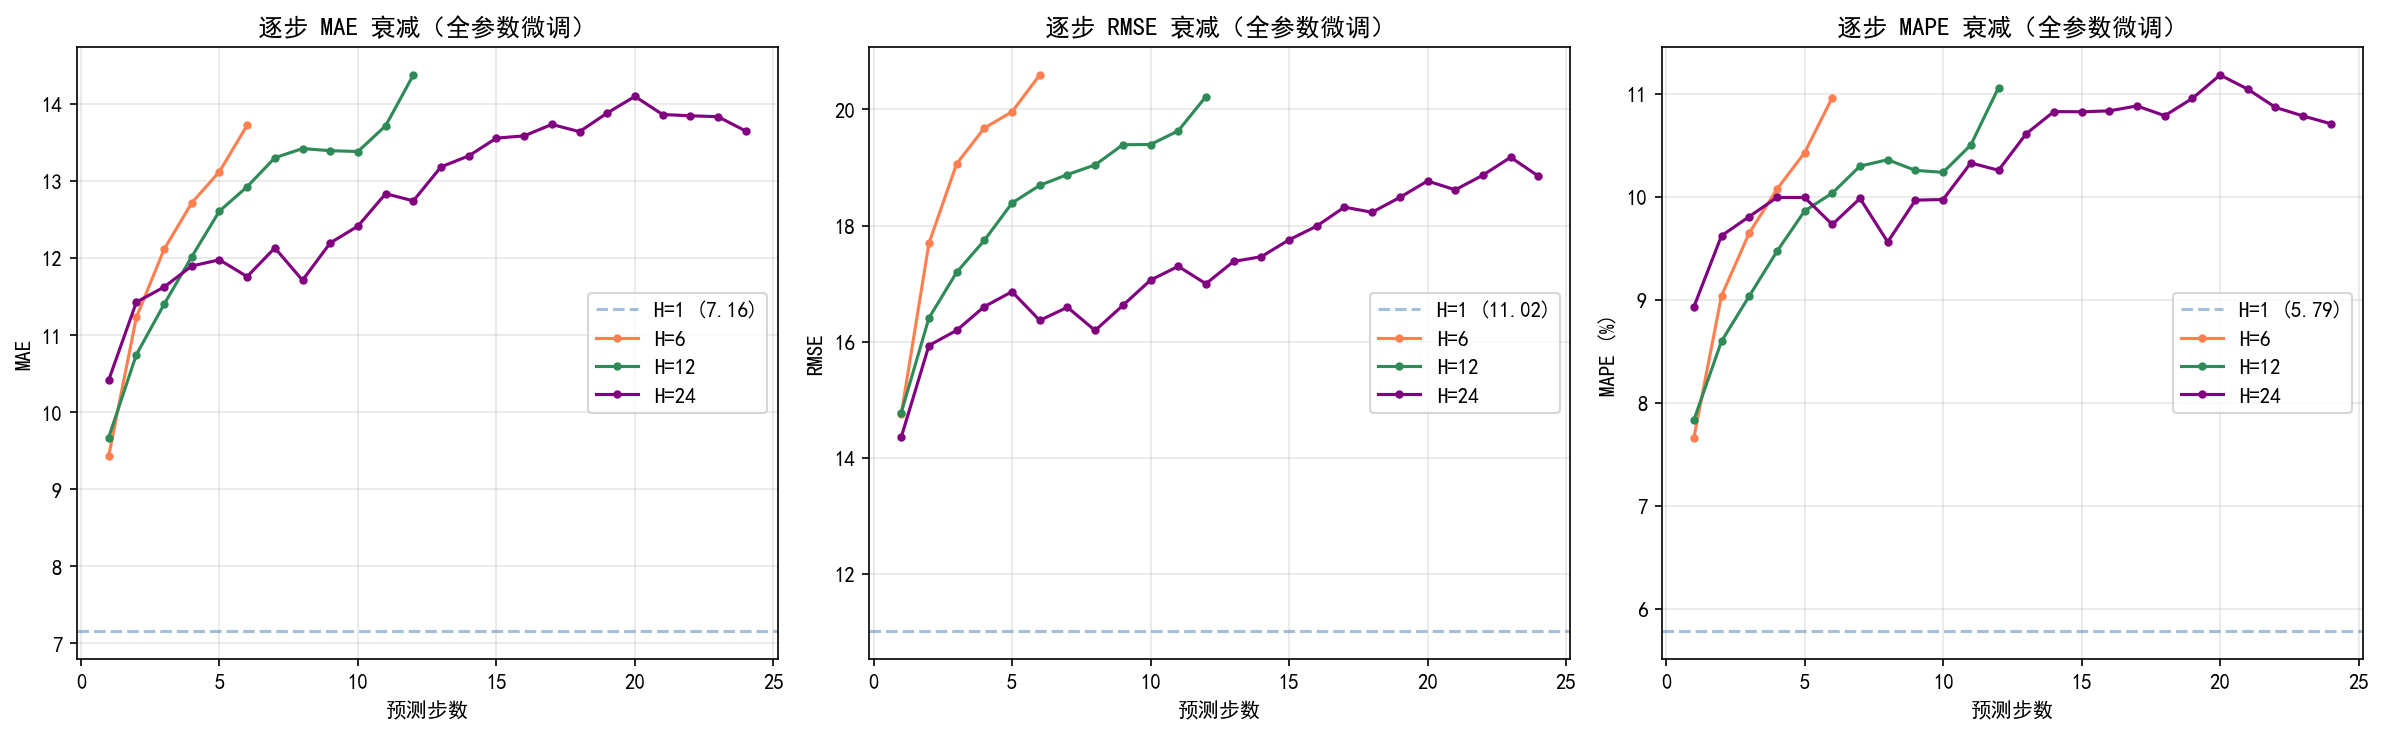

In [5]:
# 逐步精度衰减曲线（全参数微调）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
colors = {1: 'steelblue', 6: 'coral', 12: 'seagreen', 24: 'purple'}

for ax, metric in zip(axes, metrics_to_plot):
    for h in HORIZON_LIST:
        if h == 1:
            # H=1 只有1步，画水平参考线
            val = all_results[h]['finetune_per_step'].iloc[0][metric]
            ax.axhline(y=val, color=colors[h], linestyle='--', alpha=0.5,
                       label=f'H=1 ({val:.2f})')
        else:
            per_step = all_results[h]['finetune_per_step']
            ax.plot(per_step['step'], per_step[metric],
                    color=colors[h], marker='o', markersize=3, linewidth=1.5,
                    label=f'H={h}')

    ax.set_xlabel('预测步数')
    ax.set_ylabel(metric if metric != 'MAPE' else 'MAPE (%)')
    ax.set_title(f'逐步 {metric} 衰减（全参数微调）')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '多步预测_逐步衰减.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. 整体指标对比

整体指标将所有步的预测值合并计算。对于 H>1 的模型，整体指标包含了远端低精度步的贡献，因此天然不如只含 Step-1 的 H=1 模型。

In [6]:
# 整体指标对比表
overall_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    for strategy, metrics in [('Baseline', r['baseline_overall']), ('全参数微调', r['finetune_overall'])]:
        overall_rows.append({'HORIZON': h, '策略': strategy, **metrics})

overall_df = pd.DataFrame(overall_rows)
print("整体指标对比（所有预测步合并计算）")
print(overall_df.to_string(index=False, float_format='%.4f'))

整体指标对比（所有预测步合并计算）
 HORIZON       策略     MAE    RMSE  CV-RMSE    MAPE     R2
       1 Baseline  9.1092 12.9467  10.9561  7.2014 0.8982
       1    全参数微调  7.1596 11.0172   9.3232  5.7851 0.9263
       6 Baseline 13.4770 19.6109  16.5954 10.5491 0.7646
       6    全参数微调 12.0541 18.7243  15.8451  9.6352 0.7854
      12 Baseline 14.4191 18.9675  16.1364 11.6382 0.7690
      12    全参数微调 12.5790 18.3735  15.6310  9.7957 0.7832
      24 Baseline 14.9847 19.2134  16.4681 12.4618 0.7516
      24    全参数微调 12.8046 17.4117  14.9239 10.3530 0.7960


### 4. Baseline vs 全参数微调（迁移学习效果）

验证在多步预测场景下，迁移学习是否仍然有效。

In [7]:
# 迁移学习提升幅度
improve_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    bl = r['baseline_overall']
    ft = r['finetune_overall']
    improve_rows.append({
        'HORIZON': h,
        'MAE提升': f"{(bl['MAE'] - ft['MAE']) / bl['MAE'] * 100:.1f}%",
        'RMSE提升': f"{(bl['RMSE'] - ft['RMSE']) / bl['RMSE'] * 100:.1f}%",
        'MAPE提升': f"{(bl['MAPE'] - ft['MAPE']) / bl['MAPE'] * 100:.1f}%",
        'R2变化': f"{ft['R2'] - bl['R2']:.4f}",
    })

improve_df = pd.DataFrame(improve_rows)
print("全参数微调 vs Baseline 提升幅度")
print(improve_df.to_string(index=False))

全参数微调 vs Baseline 提升幅度
 HORIZON MAE提升 RMSE提升 MAPE提升   R2变化
       1 21.4%  14.9%  19.7% 0.0281
       6 10.6%   4.5%   8.7% 0.0208
      12 12.8%   3.1%  15.8% 0.0142
      24 14.5%   9.4%  16.9% 0.0444


### 5. 保存结果

In [8]:
# 保存 Step-1 对比结果
step1_df.to_csv(BASE_DIR / 'multistep_step1_comparison.csv', index=False, encoding='utf-8-sig')

# 保存逐步衰减结果
per_step_all = []
for h in HORIZON_LIST:
    for strategy, key in [('Baseline', 'baseline_per_step'), ('全参数微调', 'finetune_per_step')]:
        df = all_results[h][key].copy()
        df.insert(0, '策略', strategy)
        df.insert(0, 'HORIZON', h)
        per_step_all.append(df)

per_step_all_df = pd.concat(per_step_all, ignore_index=True)
per_step_all_df.to_csv(BASE_DIR / 'multistep_per_step_results.csv', index=False, encoding='utf-8-sig')

print(f"Step-1 对比已保存: {BASE_DIR / 'multistep_step1_comparison.csv'}")
print(f"逐步衰减结果已保存: {BASE_DIR / 'multistep_per_step_results.csv'}")

Step-1 对比已保存: data\multistep_step1_comparison.csv
逐步衰减结果已保存: data\multistep_per_step_results.csv
